Nesse notebook vamos fazer a EDA (análise exploratória) para verificar os dados que geramos e já tirar algumas métricas para o dashboard.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from utils.io.parquet import load_parquet
from utils.wfs_geosampa import GeoSampaWFSFetcher
from utils.io.static import save_static_binary_file, save_img
from tqdm import tqdm
from config import OUTPUT_DIR

In [2]:
df = load_parquet('df_final.parquet', subfolder='microdados_lotes_com_zoneamento', gdf=False, output=True)

In [3]:
df.head()

,id_pol_lote,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_tipo_lote,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,area_interseccao,id_perimetro_zoneamento,percentual_interseccao,sql
0,5967194,210,008,0053,00,F,ZMa,2024,270.751684,270.751684,536791,100.0,210.008.0053-00
1,5967202,210,011,0047,00,F,ZMa,2024,176.359862,176.359862,536783,100.0,210.011.0047-00
2,5967211,210,016,0099,00,F,ZEUa,2024,150.331192,150.331192,528202,100.0,210.016.0099-00
3,5967212,210,011,0087,00,F,ZMa,2024,145.726729,145.726729,536783,100.0,210.011.0087-00
4,5967247,210,008,0110,00,F,ZMa,2024,161.244863,161.244863,536791,100.0,210.008.0110-00


Identificando lotes com mais de um zoneamento

Os lotes com mais de um zoneamento são aqueles que:
1. o SQL aparece mais de uma vez na tabela (porque intersectou com mais de um perímetro)
2. pelo menos 2 percentuais de intersecção são significativos (tem caso que é uma intersecção tão pequena que o percentual dá o% a 3 dígitos de significância)
3. O zoneamento em si dos perímetros intersectados é diferente (porque não faz diferença se ele intersecta dois perímetros mas os dois são ZER-1 por exemplo)

In [4]:
duplicados = df[df['sql'].duplicated(keep=False)].reset_index(drop=True).sort_values(by='sql')

In [5]:
duplicados['sql'].nunique()

84293

In [6]:
prop_duplicados = duplicados['sql'].nunique()/df['sql'].nunique()
percent_duplicados = round(prop_duplicados * 100, 2)
percent_duplicados

5.04

Vou adicionando umas métricas em um dicionario para depois salvar como JSON e abrir no dashboard.

Os dados vou salvando em parquet para ficar melhor de abrir

In [7]:
metricas_dashboard = {
    'percent_lotes_mais_um_zona' : percent_duplicados
}

In [8]:
duplicados.columns

Index(['id_pol_lote', 'cd_setor_fiscal', 'cd_quadra_fiscal', 'cd_lote',
       'cd_condominio', 'cd_tipo_lote', 'cd_zoneamento_perimetro',
       'an_legislacao_zoneamento', 'area_pol_lote', 'area_interseccao',
       'id_perimetro_zoneamento', 'percentual_interseccao', 'sql'],
      dtype='str')

In [9]:
duplicados_por_sql = duplicados.groupby('sql')['percentual_interseccao'].agg(['count', 'mean', 'min', 'max']).reset_index()

In [10]:
duplicados_por_sql.head()

,sql,count,mean,min,max
0,001.001.0002-00,2,50.00,31.3,68.7
1,001.001.0003-00,5,13.54,4.1,28.8
2,001.003.0001-00,2,100.00,100.0,100.0
3,001.004.0001-00,2,100.00,100.0,100.0
4,001.006.0001-00,2,100.00,100.0,100.0


In [11]:
duplicados_por_sql['count'].min()

np.int64(2)

In [12]:
qtd_perimetros_sql_com_mais_perimetros = duplicados_por_sql['count'].max()
qtd_perimetros_sql_com_mais_perimetros

np.int64(158)

In [13]:
metricas_dashboard['qtd_perimetros_zonas_sql_com_mais_zonas'] = int(qtd_perimetros_sql_com_mais_perimetros)

In [14]:
duplicados_por_sql.loc[duplicados_por_sql['count'].argmax()]

sql      082.517.0014-00
count                158
mean            0.550633
min                  0.0
max                 10.6
Name: 26961, dtype: object

In [15]:
sql_usp = duplicados_por_sql.loc[duplicados_por_sql['count'].argmax()]['sql']
sql_usp

'082.517.0014-00'

In [16]:
df_usp = df[df['sql']==sql_usp]
df_usp.head()

,id_pol_lote,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_tipo_lote,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,area_interseccao,id_perimetro_zoneamento,percentual_interseccao,sql
612553,7193783,082,517,0014,00,F,Praça/Canteiro,2024,4.199406e+06,14187.106967,500281,0.3,082.517.0014-00
612554,7193783,082,517,0014,00,F,Praça/Canteiro,2024,4.199406e+06,2677.579555,500282,0.1,082.517.0014-00
612555,7193783,082,517,0014,00,F,Praça/Canteiro,2024,4.199406e+06,3459.506347,500283,0.1,082.517.0014-00
612556,7193783,082,517,0014,00,F,Praça/Canteiro,2024,4.199406e+06,5012.990829,500286,0.1,082.517.0014-00
612557,7193783,082,517,0014,00,F,Praça/Canteiro,2024,4.199406e+06,4992.262142,500288,0.1,082.517.0014-00


In [17]:
df_usp.shape[0]

158

In [18]:
#só uma checagem, nao deveria ter nenhum perimetro duplicado aqui pois um mesmo perimetro nao deve ser "duas vezes" interseccao
# com um mesmo lote, ou seja, o mesmo lote nao deveria ter mais de um registro de interseccção com o mesmo perimetro de zoneamento
df_usp['id_perimetro_zoneamento'].duplicated().any()

np.False_

In [19]:
perimetros_usp = df_usp['id_perimetro_zoneamento'].unique()

In [20]:
def pegar_perimetros_zonas(ls_cds_perimetros:list[str])->gpd.GeoDataFrame:
    """
    Função para pegar os perímetros de zoneamento a partir de uma lista de códigos de perímetros.
    """
    fetcher = GeoSampaWFSFetcher()
    camada_zoneamento = 'perimetro_zona_lei_18177_24'
    codigos_perimetros_formatados = ", ".join([f"'{item}'" for item in ls_cds_perimetros])
    filtro_lista = f"cd_identificador IN ({codigos_perimetros_formatados})"
    
    perimetros_selecionados = []
    for batch in fetcher(camada_zoneamento, cql_filter=filtro_lista):
        perimetros_selecionados.extend(batch)
    gdf_perimetros = gpd.GeoDataFrame.from_features(perimetros_selecionados, crs='EPSG:31983')

    return gdf_perimetros
    

In [21]:
def pegar_lote(cd_setor:str, cd_quadra:str, cd_lote:str, cd_condominio:str)->gpd.GeoDataFrame:

    camada_lote ='lote_cidadao'
    filtro_lote = f"cd_setor_fiscal='{cd_setor}' AND cd_quadra_fiscal='{cd_quadra}' AND cd_lote='{cd_lote}' AND cd_condominio = '{cd_condominio}'"
    fetcher = GeoSampaWFSFetcher()
    lote = []
    for batch in fetcher(camada_lote, cql_filter=filtro_lote):
        lote.extend(batch)
    gdf_lote = gpd.GeoDataFrame.from_features(lote, crs='EPSG:31983')
    return gdf_lote


In [22]:
gdf_perimetros_usp = pegar_perimetros_zonas(perimetros_usp)
setor_usp = sql_usp.split('.')[0]
quadra_usp = sql_usp.split('.')[1]
lote_usp = sql_usp.split('.')[2].split('-')[0]
condominio_usp = sql_usp.split('.')[2].split('-')[1]
gdf_lote_usp = pegar_lote(cd_setor=setor_usp, cd_quadra=quadra_usp, cd_lote=lote_usp, cd_condominio=condominio_usp)

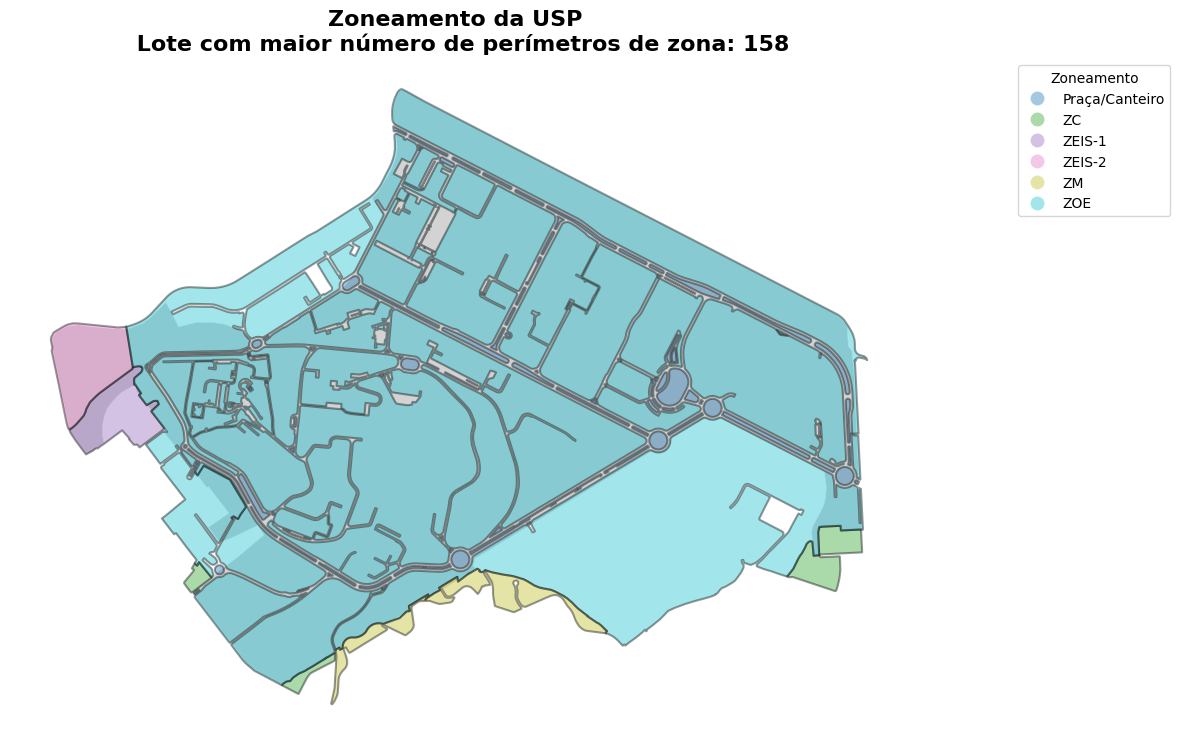

In [23]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_lote_usp.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)

ax.set_title(f"Zoneamento da USP \n Lote com maior número de perímetros de zona: {qtd_perimetros_sql_com_mais_perimetros}", fontsize=16, fontweight='bold')
gdf_perimetros_usp.plot(
    ax=ax, 
    column='cd_zoneamento_perimetro', 
    categorical=True, 
    legend=True, 
    alpha=0.4, 
    edgecolor='black', 
    linewidth=1.5,
    legend_kwds={'title': "Zoneamento", 'bbox_to_anchor': (1.3, 1)}
)

ax.set_axis_off()
plt.tight_layout()
save_img("zoneamento_da_usp.png", fig)
plt.show()

In [24]:
gdf_perimetros_usp['cd_zoneamento_perimetro'].value_counts()

cd_zoneamento_perimetro
Praça/Canteiro    115
ZOE                36
ZC                  4
ZEIS-1              1
ZEIS-2              1
ZM                  1
Name: count, dtype: int64

Mas olhando a USP vemos que em vários casos a interseccção é muito pequena, quase que uma "linha" só conflitando.

Vamos identificar esses casos ao identificar os sqls cuja interseccção mínima com perímetros de zoneamento é correspondente a 0% da área do lote.

In [25]:
duplicados_por_sql.head()

,sql,count,mean,min,max
0,001.001.0002-00,2,50.00,31.3,68.7
1,001.001.0003-00,5,13.54,4.1,28.8
2,001.003.0001-00,2,100.00,100.0,100.0
3,001.004.0001-00,2,100.00,100.0,100.0
4,001.006.0001-00,2,100.00,100.0,100.0


In [26]:
prop_sql_com_perimetros_interseccao_irrisoria = float((duplicados_por_sql['min']==0).mean())
metricas_dashboard['percent_sql_com_zonas_interseccao_irrisoria'] = round(prop_sql_com_perimetros_interseccao_irrisoria, 2)*100
metricas_dashboard

{'percent_lotes_mais_um_zona': 5.04,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 53.0}

Vamos avançar nas métricas e calcular a média de zonas por sql, para os sql que tem mais de uma zona

In [27]:
media_perimetros_por_sql = round(float(duplicados_por_sql['count'].mean()), 1)
metricas_dashboard['media_de_zonas_por_sql'] = media_perimetros_por_sql
metricas_dashboard


{'percent_lotes_mais_um_zona': 5.04,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 53.0,
 'media_de_zonas_por_sql': 2.1}

In [28]:
mediana_perimetros_por_sql = round(float(duplicados_por_sql['count'].median()), 1)
metricas_dashboard['mediana_de_zonas_por_sql'] = mediana_perimetros_por_sql
metricas_dashboard


{'percent_lotes_mais_um_zona': 5.04,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 53.0,
 'media_de_zonas_por_sql': 2.1,
 'mediana_de_zonas_por_sql': 2.0}

Text(0.5, 1.0, 'Distribuição do número de perímetros de zoneamento por SQL')

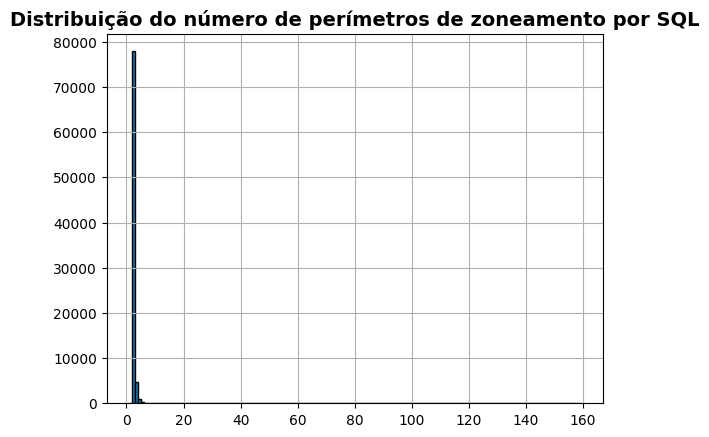

In [29]:
axis = duplicados_por_sql['count'].hist(bins=range(1, qtd_perimetros_sql_com_mais_perimetros+2), edgecolor='black',)
axis.set_title("Distribuição do número de perímetros de zoneamento por SQL", fontsize=14, fontweight='bold')

In [30]:
duplicados_por_sql['count'].value_counts(normalize=True)[:5]

count
2    0.924015
3    0.055888
4    0.012279
5    0.003915
6    0.001708
Name: proportion, dtype: float64

In [31]:
moda = duplicados_por_sql['count'].mode()
metricas_dashboard['moda_de_zonas_por_sql'] = int(moda[0])

metricas_dashboard['percentual_lotes_com_duas_zonas'] = round(float(duplicados_por_sql['count'].value_counts(normalize=True).get(2, 0))*100, 2)
metricas_dashboard

{'percent_lotes_mais_um_zona': 5.04,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 53.0,
 'media_de_zonas_por_sql': 2.1,
 'mediana_de_zonas_por_sql': 2.0,
 'moda_de_zonas_por_sql': 2,
 'percentual_lotes_com_duas_zonas': 92.4}

Agora que já tiramos todas as métricas, vamos analisar os dados considerando as zonas únicas

In [32]:
areas_intersec_por_tipo_zona = df.groupby(['sql', 'cd_zoneamento_perimetro'])['area_interseccao'].sum().reset_index()
areas_intersec_por_tipo_zona.head()

,sql,cd_zoneamento_perimetro,area_interseccao
0,001.001.0002-00,Praça/Canteiro,1652.533133
1,001.001.0002-00,ZC,753.836627
2,001.001.0003-00,Praça/Canteiro,4375.522818
3,001.002.0001-00,Praça/Canteiro,3843.730094
4,001.002.0002-00,Praça/Canteiro,1252.565401


Agora se vermos o caso da USP, vemos que ele só tem 6 zonas únicas, como o gráfico mostrava.

Mas para calcularmos os percentuais de intersecção precisamos retomar os dados que ficaram no df original, como a área do lote, que não poderiam ser agrupados pois resultaria em somar várias vezes a área do mesmo lote (no caso da USP). (a rigor até poderia ter somado os percentuais de intersecção, mas acho melhor recalcular pois vai perder precisão)

In [33]:
usp = areas_intersec_por_tipo_zona.loc[areas_intersec_por_tipo_zona['sql']==sql_usp]
usp.shape

(6, 3)

In [34]:
usp

,sql,cd_zoneamento_perimetro,area_interseccao
588857,082.517.0014-00,Praça/Canteiro,1.527425e+05
588858,082.517.0014-00,ZC,9.295623e+02
588859,082.517.0014-00,ZEIS-1,3.627188e+04
588860,082.517.0014-00,ZEIS-2,1.031548e+05
588861,082.517.0014-00,ZM,1.547457e+03
588862,082.517.0014-00,ZOE,3.415986e+06


Mas antes disso precisamos investigar uma questão, que é o fato de haver SQLs duplicados.

In [35]:
#note que o dataframe original nao tem linhas duplicadas. 
df.duplicated().any()

np.False_

Veja abaixo que a chave primária não é um SQL com um perímetro de zoneamento, como pensaríamos originalmente sobre a forma como os dados foram construídos.

Isso porque como vimos anteriormente, há SQLs duplicados.

In [36]:
df[['sql', 'id_perimetro_zoneamento']].duplicated().any()

np.True_

In [37]:
df[['sql', 'id_perimetro_zoneamento']].duplicated().sum()

np.int64(6225)

A chave é um id de polígono de lote com um id de perímetro de zoneamento.

In [38]:
df[['id_pol_lote', 'id_perimetro_zoneamento']].duplicated().any()

np.False_

Veja que um mesmo SLQ pode ter mais de um id de polígono de lote

In [39]:
#abaixo vamos dropar as duplicatas pois elas dizem respeito aos perimetros de zoneamento qeu pode ter mais de um
df_sql = df[['sql', 'id_pol_lote', 'cd_tipo_lote']].drop_duplicates()
df_sql['sql'].duplicated().sum()

np.int64(10147)

In [40]:
df_sqls_duplicados = df_sql[df_sql['sql'].duplicated(keep=False)].sort_values(by='sql')
df_sqls_duplicados.head()

,sql,id_pol_lote,cd_tipo_lote
1202797,001.003.0001-00,1979119,V
1203125,001.003.0001-00,1998250,F
1202713,001.004.0001-00,1974225,F
1203733,001.004.0001-00,2031689,V
1203730,001.006.0001-00,2031468,F


A princípio eu pensei que eles estavam duplicados porque são tipos de lotes diferentes, mas mesmo assim existem alguns SQLs duplicados para valer (com o mesmo tipo de lote.)

In [41]:
df_sqls_duplicados[['sql', 'cd_tipo_lote']].duplicated().mean()

np.float64(0.015873813231526597)

In [42]:
df_sqls_duplicados[df_sqls_duplicados[['sql', 'cd_tipo_lote']].duplicated(keep=False)]

,sql,id_pol_lote,cd_tipo_lote
1203075,001.012.0001-00,1995066,M
1204396,001.012.0001-00,7095737,M
193285,004.003.0001-00,2142276,M
193820,004.003.0001-00,2162154,M
193566,004.004.0001-00,2152715,M
...,...,...,...
14232,307.003.0001-00,6753578,M
14292,307.003.0003-00,6753968,M
16126,307.003.0003-00,7348942,M
11956,307.003.0004-00,6734721,M


A grande maior parte desses sqls duplicados são municipais, mas alguns deles são fiscais.

In [43]:
df_sqls_duplicados[df_sqls_duplicados[['sql', 'cd_tipo_lote']].duplicated(keep=False)]['cd_tipo_lote'].value_counts()

cd_tipo_lote
M    622
F     10
Name: count, dtype: int64

Vou salvar para analisar depois e confrontar com a equipe. A conclusão principal é qeu ainda precisamos usar o id do poligono do lote como index

In [44]:
metricas_dashboard['sqls_duplicados'] = list(df_sqls_duplicados['sql'].unique())

Agora vou preparar os dados para poder fazer a soma das áreas dos perímetros de zona para ficar apenas com os tipos de zona únicos (equivalente a dar um "melt" no tipo de zona por lote). Como vimos temos que usar o poligono do lote nao o SQL como index para o groupby

In [45]:
#abaixo pegamos só o id do polígono do lote, o código do zoneamento e a área de interseção
#com isso conseguimos dar groupby por lote e tipo de zona, tendo a área de interseccao por tipo de zona
area_por_tipo_zoneamento = df[['id_pol_lote', 'cd_zoneamento_perimetro', 'area_interseccao']].groupby(['id_pol_lote', 'cd_zoneamento_perimetro'])['area_interseccao'].sum().reset_index()
area_por_tipo_zoneamento.head()

,id_pol_lote,cd_zoneamento_perimetro,area_interseccao
0,1957324,ZEU,102.542849
1,1957325,ZEU,117.503100
2,1957326,ZM,156.747523
3,1957327,ZC,73.816724
4,1957328,ZEU,670.704125


In [46]:
area_por_tipo_zoneamento['id_pol_lote'].duplicated().any()

np.True_

In [47]:
area_por_tipo_zoneamento['id_pol_lote'].duplicated().mean()

np.float64(0.042319458660297966)

Aqui observamos os casos em que um mesmo polígono de lote está em mais de um zoneamento

In [48]:
area_por_tipo_zoneamento[area_por_tipo_zoneamento['id_pol_lote'].duplicated(keep=False)].head()

,id_pol_lote,cd_zoneamento_perimetro,area_interseccao
8,1957333,ZCOR-2,0.182365
9,1957333,ZCOR-3,368.324152
10,1957333,ZER-1,0.016592
15,1957339,ZCOR-2,286.112583
16,1957339,ZCOR-3,0.000271


In [49]:
area_por_tipo_zoneamento[area_por_tipo_zoneamento['id_pol_lote'].duplicated(keep=False)].head()

,id_pol_lote,cd_zoneamento_perimetro,area_interseccao
8,1957333,ZCOR-2,0.182365
9,1957333,ZCOR-3,368.324152
10,1957333,ZER-1,0.016592
15,1957339,ZCOR-2,286.112583
16,1957339,ZCOR-3,0.000271


Vamos visualizar o caso da USP

In [50]:
id_pol_usp = df_usp['id_pol_lote'].unique()[0]
area_por_tipo_zoneamento[area_por_tipo_zoneamento['id_pol_lote']==id_pol_usp]

,id_pol_lote,cd_zoneamento_perimetro,area_interseccao
1713231,7193783,Praça/Canteiro,1.527425e+05
1713232,7193783,ZC,9.295623e+02
1713233,7193783,ZEIS-1,3.627188e+04
1713234,7193783,ZEIS-2,1.031548e+05
1713235,7193783,ZM,1.547457e+03
1713236,7193783,ZOE,3.415986e+06


Agora podemos voltar no dataframe original, dropar a área de intersecção original e os ids dos polígonos do zoneamento originais, dropar as linhas repetidas e dar merge. Assim teremos os dados agrupados pela área de interseccção por tipo de zona

In [51]:
df_microdados_final = df.drop(columns=['id_perimetro_zoneamento', 'area_interseccao', 'percentual_interseccao'])
df_microdados_final = df_microdados_final.reset_index(drop=True)
df_microdados_final.head()

,id_pol_lote,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_tipo_lote,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,sql
0,5967194,210,008,0053,00,F,ZMa,2024,270.751684,210.008.0053-00
1,5967202,210,011,0047,00,F,ZMa,2024,176.359862,210.011.0047-00
2,5967211,210,016,0099,00,F,ZEUa,2024,150.331192,210.016.0099-00
3,5967212,210,011,0087,00,F,ZMa,2024,145.726729,210.011.0087-00
4,5967247,210,008,0110,00,F,ZMa,2024,161.244863,210.008.0110-00


Como agora nós vamos indexar pelo id do polígono do lote e pelo tipo de zoneamento, temos que dropar as duplicadas para esses casos (que seriam os zoneamentos de mesmo tipo com muitos polígonos como é o caso da USP)

In [52]:
df_microdados_final[['id_pol_lote', 'cd_zoneamento_perimetro']].duplicated().any()

np.True_

Veja que é algo raro mas como estamos trabalhando com muitos dados o valor absoluto é grande, chega a quase 10 mil

In [53]:
df_microdados_final[['id_pol_lote', 'cd_zoneamento_perimetro']].duplicated().sum()

np.int64(9599)

In [54]:
df_microdados_final[['id_pol_lote', 'cd_zoneamento_perimetro']].duplicated().mean()

np.float64(0.005428687608125556)

In [55]:
dropar_duplicados = df_microdados_final[df_microdados_final[['id_pol_lote', 'cd_zoneamento_perimetro']].duplicated(keep='first')].index
df_microdados_final = df_microdados_final.drop(index=dropar_duplicados)

In [56]:
df_microdados_final[['id_pol_lote', 'cd_zoneamento_perimetro']].duplicated().any()

np.False_

In [57]:
df_microdados_final['id_pol_lote'].duplicated().any()

np.True_

In [58]:
df_microdados_final[df_microdados_final['sql']==sql_usp]

,id_pol_lote,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_tipo_lote,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,sql
612553,7193783,082,517,0014,00,F,Praça/Canteiro,2024,4.199406e+06,082.517.0014-00
612668,7193783,082,517,0014,00,F,ZC,2024,4.199406e+06,082.517.0014-00
612672,7193783,082,517,0014,00,F,ZEIS-1,2024,4.199406e+06,082.517.0014-00
612673,7193783,082,517,0014,00,F,ZEIS-2,2024,4.199406e+06,082.517.0014-00
612674,7193783,082,517,0014,00,F,ZOE,2024,4.199406e+06,082.517.0014-00
612710,7193783,082,517,0014,00,F,ZM,2024,4.199406e+06,082.517.0014-00


Entao podemos dar o merge

In [59]:
df_microdados_final = pd.merge(df_microdados_final, area_por_tipo_zoneamento, on=['id_pol_lote', 'cd_zoneamento_perimetro'], how='outer')

E recalcular o percentual de intersecção

In [60]:
df_microdados_final['percentual_area_interseccao'] = (df_microdados_final['area_interseccao'] / df_microdados_final['area_pol_lote']).round(2)*100

In [61]:
df_microdados_final['percentual_area_interseccao'].max()

np.float64(200.0)

In [62]:
df_microdados_final['percentual_area_interseccao'].min()

np.float64(0.0)

In [63]:
df_microdados_final['percentual_area_interseccao'].value_counts()

percentual_area_interseccao
100.0    1660165
0.0        57054
99.0        7258
1.0         5743
98.0        3003
          ...   
188.0          1
108.0          1
197.0          1
173.0          1
136.0          1
Name: count, Length: 121, dtype: int64

In [64]:
pols_lotes_intrseccao_mais_100 = df_microdados_final[df_microdados_final['percentual_area_interseccao']>100]['id_pol_lote'].unique()

In [65]:
len(pols_lotes_intrseccao_mais_100)

314

Como podemos ver abaixo, tem poligonos de lotes que tem mais de 100% de área de intersecção porque provavlemente os perímetros das zonas se sobrepõe.

In [66]:
# mas é raro, menos de 0.01% dos lotes
len(pols_lotes_intrseccao_mais_100)/df_microdados_final['id_pol_lote'].nunique()

0.00018644121134536336

Olha aqui no caso como tem 2 ZMa que soam mais de 100% da área do lote como intersecção.

In [67]:
df[df['id_pol_lote'].isin(pols_lotes_intrseccao_mais_100)][['id_pol_lote', 'sql', 'area_interseccao', 'area_pol_lote', 'percentual_interseccao', 'cd_zoneamento_perimetro']].head()

,id_pol_lote,sql,area_interseccao,area_pol_lote,percentual_interseccao,cd_zoneamento_perimetro
62653,3687278,163.027.0013-00,4.701205,2614.509882,0.2,ZEPAM
62654,3687278,163.027.0013-00,2609.808676,2614.509882,99.8,ZMa
62655,3687278,163.027.0013-00,975.318272,2614.509882,37.3,ZMa
62656,3687278,163.027.0013-00,975.318272,2614.509882,37.3,ZEPAM
64214,7216291,163.027.0014-00,34.112228,4516.039456,0.8,ZEPAM


Agora podemos atualizar o percentual de lotes com mais que uma zona considerando o tipo de zona. Como esperávamos, o percentual é menor.

In [68]:
percent_lotes_mais_um_tipo_zona = round(float(df_microdados_final['id_pol_lote'].duplicated().mean())*100, 2)
metricas_dashboard['percent_lotes_mais_um_tipo_zona'] = percent_lotes_mais_um_tipo_zona
percent_lotes_mais_um_tipo_zona

4.23

In [69]:
metricas_dashboard['percent_lotes_mais_um_zona']

5.04

Abaixo pegamos os dados da USP para validar se deu certo.

In [70]:
df_microdados_final[df_microdados_final['id_pol_lote']==id_pol_usp]

,id_pol_lote,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_tipo_lote,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,sql,area_interseccao,percentual_area_interseccao
1713231,7193783,082,517,0014,00,F,Praça/Canteiro,2024,4.199406e+06,082.517.0014-00,1.527425e+05,4.0
1713232,7193783,082,517,0014,00,F,ZC,2024,4.199406e+06,082.517.0014-00,9.295623e+02,0.0
1713233,7193783,082,517,0014,00,F,ZEIS-1,2024,4.199406e+06,082.517.0014-00,3.627188e+04,1.0
1713234,7193783,082,517,0014,00,F,ZEIS-2,2024,4.199406e+06,082.517.0014-00,1.031548e+05,2.0
1713235,7193783,082,517,0014,00,F,ZM,2024,4.199406e+06,082.517.0014-00,1.547457e+03,0.0
1713236,7193783,082,517,0014,00,F,ZOE,2024,4.199406e+06,082.517.0014-00,3.415986e+06,81.0


In [71]:
df_microdados_final[df_microdados_final['id_pol_lote']==id_pol_usp].shape

(6, 12)

Por fim vamos apenas adicionar uma flag para o caso em que há mais que 100% de cobertura do lote por perímetros de zoneamento

In [72]:
percent_intercecao_por_lote = df_microdados_final.groupby('id_pol_lote')['percentual_area_interseccao'].sum().reset_index().rename(columns={'percentual_area_interseccao' : 'percentual_area_interseccao_total'})

In [73]:
percent_intercecao_por_lote['sobreposicao_zonas'] = percent_intercecao_por_lote['percentual_area_interseccao_total']>100
percent_lotes_com_sobreposicao_de_zonas = round(float(percent_intercecao_por_lote['sobreposicao_zonas'].mean()), 2)*100
metricas_dashboard['percent_lotes_com_sobreposicao_de_zonas'] = percent_lotes_com_sobreposicao_de_zonas
percent_lotes_com_sobreposicao_de_zonas

0.0

In [74]:
(percent_intercecao_por_lote['percentual_area_interseccao_total']<100).any()

np.True_

In [75]:
percent_intercecao_por_lote['area_sem_zona'] = percent_intercecao_por_lote['percentual_area_interseccao_total']<100
percent_lotes_com_area_sem_zona = round(float(percent_intercecao_por_lote['area_sem_zona'].mean()), 2)*100
metricas_dashboard['percent_lotes_com_area_sem_zona'] = percent_lotes_com_area_sem_zona
percent_lotes_com_area_sem_zona



1.0

In [76]:
df_microdados_final.shape

(1758600, 12)

In [77]:
df_microdados_final = pd.merge(df_microdados_final, percent_intercecao_por_lote, on='id_pol_lote', how='left')
df_microdados_final.shape

(1758600, 15)

In [78]:
#checando porque os dois sao mutuamente excludentes
(df_microdados_final['area_sem_zona']&df_microdados_final['sobreposicao_zonas']).any() == False

np.True_

Agora vou calcular a representatividade da zona em relação à área de intersecção total do zoneamento com o lote (é importante usar o percentual da área de intersecção totla porque como vimos há sobreposições)

In [79]:
df_microdados_final['importancia_zona_para_lote'] = (df_microdados_final['percentual_area_interseccao']/df_microdados_final['percentual_area_interseccao_total']).round(2)*100
df_microdados_final.head()

,id_pol_lote,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_tipo_lote,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,sql,area_interseccao,percentual_area_interseccao,percentual_area_interseccao_total,sobreposicao_zonas,area_sem_zona,importancia_zona_para_lote
0,1957324,027,026,0019,00,F,ZEU,2024,102.542849,027.026.0019-00,102.542849,100.0,100.0,False,False,100.0
1,1957325,027,026,0020,00,F,ZEU,2024,117.503100,027.026.0020-00,117.503100,100.0,100.0,False,False,100.0
2,1957326,030,131,0011,00,F,ZM,2024,156.747523,030.131.0011-00,156.747523,100.0,100.0,False,False,100.0
3,1957327,018,070,0018,00,F,ZC,2024,73.816724,018.070.0018-00,73.816724,100.0,100.0,False,False,100.0
4,1957328,016,102,0000,08,F,ZEU,2024,670.704125,016.102.0000-08,670.704125,100.0,100.0,False,False,100.0


O valor máximo somando todas as zonas deu um pouquinho mais que 100% por conta de erro de arredondamento, acho que não tem problema.

In [80]:
df_microdados_final.groupby('id_pol_lote')['importancia_zona_para_lote'].sum().max()

np.float64(101.0)

In [81]:
df_microdados_final.groupby('id_pol_lote')['importancia_zona_para_lote'].sum().min()

np.float64(0.0)

In [82]:
df_microdados_final['importancia_zona_para_lote'].max()

np.float64(100.0)

In [83]:
df_microdados_final['importancia_zona_para_lote'].min()

np.float64(0.0)

Antes de salvar precisamos só acrescentar uma coluna que é uma list com os ids dos perimetros de zoneamento vinculados àquele lote (temos essa info no df original). Isso é necessário para depois poder fazer a busca no geosampa e poder plotar eles.

In [84]:
mapper_id_pol_zoneamento = df.groupby("id_pol_lote")["id_perimetro_zoneamento"].apply(list).to_dict()

In [85]:
#aqui tem que dar 158 porque sabemos que a USP "corta" 158 perimetros de zoneamento diferentes
len(mapper_id_pol_zoneamento[id_pol_usp])

158

In [86]:
df_microdados_final['lst_id_perimetro_zoneamento'] = df_microdados_final['id_pol_lote'].map(mapper_id_pol_zoneamento)
df_microdados_final['lst_id_perimetro_zoneamento']= df_microdados_final['lst_id_perimetro_zoneamento'].apply(lambda x: ';'.join(str(i) for i in x))
df_microdados_final['lst_id_perimetro_zoneamento'].sample(3)

915121     535126
1227376    517319
143100     559353
Name: lst_id_perimetro_zoneamento, dtype: str

Ok acho que já temos todos os dados que precisamos, vamos salvar eles.

In [87]:
from utils.io.parquet import save_parquet
from utils.io.static import save_json

In [88]:
save_parquet(df_microdados_final, 'df_microdados_final.parquet', subfolder='dados_dashboard', output=True)

PosixPath('/home/hpougy/projects/zoneamento_lotes_pmsp/output/dados_dashboard/df_microdados_final.parquet')

In [89]:
save_json('metricas_dashboard.json', metricas_dashboard)

'/home/hpougy/projects/zoneamento_lotes_pmsp/output/static/metricas_dashboard.json'

In [90]:
df_microdados_final.head()

,id_pol_lote,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_tipo_lote,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,sql,area_interseccao,percentual_area_interseccao,percentual_area_interseccao_total,sobreposicao_zonas,area_sem_zona,importancia_zona_para_lote,lst_id_perimetro_zoneamento
0,1957324,027,026,0019,00,F,ZEU,2024,102.542849,027.026.0019-00,102.542849,100.0,100.0,False,False,100.0,531360
1,1957325,027,026,0020,00,F,ZEU,2024,117.503100,027.026.0020-00,117.503100,100.0,100.0,False,False,100.0,531360
2,1957326,030,131,0011,00,F,ZM,2024,156.747523,030.131.0011-00,156.747523,100.0,100.0,False,False,100.0,553432
3,1957327,018,070,0018,00,F,ZC,2024,73.816724,018.070.0018-00,73.816724,100.0,100.0,False,False,100.0,516036
4,1957328,016,102,0000,08,F,ZEU,2024,670.704125,016.102.0000-08,670.704125,100.0,100.0,False,False,100.0,558112


Voltando ao exemplo da USP vemos agora que apesar de ter muitos canteiros, o zoneamento mais importante de longe é ZOE

In [91]:
df_microdados_final[df_microdados_final['id_pol_lote']==id_pol_usp][['id_pol_lote', 'cd_zoneamento_perimetro', 'percentual_area_interseccao', 'percentual_area_interseccao_total', 'importancia_zona_para_lote']]

,id_pol_lote,cd_zoneamento_perimetro,percentual_area_interseccao,percentual_area_interseccao_total,importancia_zona_para_lote
1713231,7193783,Praça/Canteiro,4.0,88.0,5.0
1713232,7193783,ZC,0.0,88.0,0.0
1713233,7193783,ZEIS-1,1.0,88.0,1.0
1713234,7193783,ZEIS-2,2.0,88.0,2.0
1713235,7193783,ZM,0.0,88.0,0.0
1713236,7193783,ZOE,81.0,88.0,92.0


In [92]:
metricas_dashboard.pop('sqls_duplicados')
metricas_dashboard

{'percent_lotes_mais_um_zona': 5.04,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 53.0,
 'media_de_zonas_por_sql': 2.1,
 'mediana_de_zonas_por_sql': 2.0,
 'moda_de_zonas_por_sql': 2,
 'percentual_lotes_com_duas_zonas': 92.4,
 'percent_lotes_mais_um_tipo_zona': 4.23,
 'percent_lotes_com_sobreposicao_de_zonas': 0.0,
 'percent_lotes_com_area_sem_zona': 1.0}